# C. elegans Connectome Analysis

C. elegans is a roundworm whose neural connectome has been rigorously studied over the last several decades (see [https://wormwiring.org/](https://wormwiring.org/) for more details). Here we apply the method of conditional clique homology to evaluate the topology induced by the prescribed functional neuron classification of [Cook et al.](https://www.nature.com/articles/s41586-019-1352-7) (2019).

## Methods

Connectomics data and functional neuron classifications were obtained from the Emmons Laboratory WormWiring database (wormwiring.org) version 1.1 (April 18, 2020), as described in Cook et al.

**this is where we talk about what specific data model we are actually analyzing*

## Analysis

In [ ]:
import numpy as np
import sys

# Prevent output truncation
np.set_printoptions(threshold=sys.maxsize)

from matplotlib import pyplot as plt
import networkit as nk
import networkx as nx

from clique_homology.stats_engine.stats_engine import StatsEngine
from c_elegans_colors import c_elegans_colors
from c_elegans_edges import c_elegans_edges

In [ ]:
# import edges and functional groupings
edges = c_elegans_edges()
neurons, integer_labels, groups = c_elegans_colors()

# show edges data
print("Edges (head):", [edge for edge in edges[:5]])
# show group data
print("Neuron Groupings (head):", [group for group in groups[:5]])

Edges (head): [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
Neuron Groupings (head): [0, 0, 0, 0, 0]


### Convert to a Networkit Graph

In [ ]:
# initialize networkit Graph object
number_of_nodes = len(neurons)
G = nk.Graph(number_of_nodes, weighted=False, directed=False)


# add edges to the graph
for node1, node2 in edges:
    G.addEdge(node1, node2)

# self-loops are disallowed
G.removeSelfLoops()

### Compute Conditional Clique Homology

In [ ]:
SE = StatsEngine(
    G=G,
    labels=[str(group) for group in groups]
)

In [ ]:
n = 2000
p, obsD2, nullD2 = SE.pval(iters=n)
print("quantile:", p)
print("Mahalanobis distance of the observed grouping:", obsD2)
print("Average Mahalanobis distance:", sum(nullD2) / n)

[[ 7.42529425e+01 -1.26976988e+01 -9.97098549e-02  5.57278639e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-1.26976988e+01  1.74822505e+02 -2.29971236e+00 -4.34279640e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-9.97098549e-02 -2.29971236e+00  1.55575288e+00 -1.76338169e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 5.57278639e-03 -4.34279640e-02 -1.76338169e-03  2.49499750e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.0000000

### Results

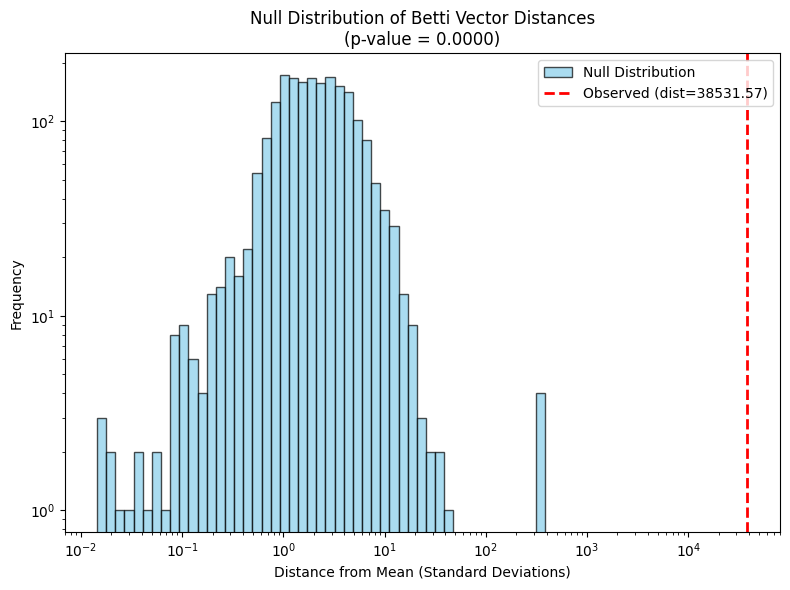

In [ ]:
from clique_homology.stats_engine.visualization import plot_null_distribution
plot_null_distribution(nullD2, obsD2, p)

In [ ]:
SE.observed_betti()

array([135,  96,  31,  10,   0,   0,   0,   0,   0])

In [ ]:
SE.null_betti[:10, :]

array([[122, 105,   0,   0,   0,   0,   0,   0,   0],
       [126, 115,   1,   0,   0,   0,   0,   0,   0],
       [128,  95,   0,   0,   0,   0,   0,   0,   0],
       [118, 137,   1,   0,   0,   0,   0,   0,   0],
       [131, 106,   0,   0,   0,   0,   0,   0,   0],
       [111, 112,   0,   0,   0,   0,   0,   0,   0],
       [122, 127,   1,   0,   0,   0,   0,   0,   0],
       [126, 100,   1,   0,   0,   0,   0,   0,   0],
       [114, 126,   1,   0,   0,   0,   0,   0,   0],
       [132, 109,   1,   0,   0,   0,   0,   0,   0]])

C:\Users\andre\AppData\Local\Temp\ipykernel_2144\3946189658.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


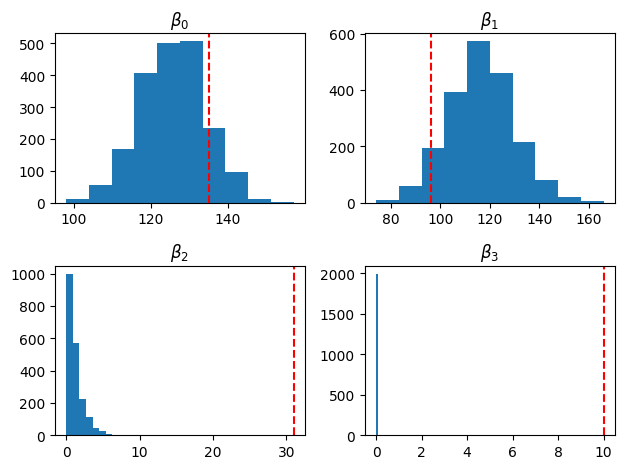

In [ ]:
fig, axs = plt.subplots(2, 2)
axs = axs.flatten()
num_plots = min(4, SE.null_betti.shape[1]) 

for i in range(num_plots):
    axs[i].hist(SE.null_betti[:, i])
    axs[i].set_title(r"$\beta_{" + str(i) + "}$") 
    axs[i].axvline(x=SE.obs_betti[i], color="red", linestyle="--")

fig.tight_layout()
fig.show()

## Configuration Model

In [ ]:
H = nx.Graph(edges)
H.remove_edges_from(nx.selfloop_edges(H))
config = nx.Graph(nx.configuration_model([d for n, d in H.degree()]))

In [ ]:
config_int_labels = nx.convert_node_labels_to_integers(config)
# Then convert to NetworKit
Hnk = nk.nxadapter.nx2nk(config_int_labels)
Hnk.removeSelfLoops()

H_SE = StatsEngine(Hnk, [str(group) for group in groups])

In [ ]:
n = 2000
Hp, HobsD2, HnullD2 = H_SE.pval(iters=n)

[[ 6.80272574e+01 -1.50870485e+01 -2.37618809e-05  0.00000000e+00
   0.00000000e+00]
 [-1.50870485e+01  4.87195034e+02 -6.88244122e-03  0.00000000e+00
   0.00000000e+00]
 [-2.37618809e-05 -6.88244122e-03  5.00000000e-04  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]]


In [ ]:
H_SE.obs_betti

array([167, 331,   0,   0,   0])

In [ ]:
H_SE.null_betti[:10, :]

array([[113, 279,   0,   0,   0],
       [114, 265,   0,   0,   0],
       [115, 261,   0,   0,   0],
       [115, 305,   0,   0,   0],
       [115, 272,   0,   0,   0],
       [117, 264,   0,   0,   0],
       [128, 292,   0,   0,   0],
       [107, 272,   0,   0,   0],
       [124, 248,   0,   0,   0],
       [115, 265,   0,   0,   0]])

In [ ]:
H_SE_WholeGraph = StatsEngine(Hnk, [str(0)]*Hnk.numberOfNodes())

In [ ]:
H_SE.observed_betti()

array([167, 331,   0,   0,   0])

In [ ]:
max(len(c) for c in nx.find_cliques(config))

5

In [ ]:
max(len(c) for c in nx.find_cliques(H))

9

### Results

Looks like the configuration model produces almost no higher-dimensional holes. Additionally, the maximum size of a clique is much lower.

## Betti Profile of the Whole Graph

In [ ]:
WholeGraph = StatsEngine(G, [str(0)]*G.numberOfNodes())

In [ ]:
WholeGraph.observed_betti()

array([  1, 293, 126,  18,   0,   0,   0,   0,   0])

So it looks like any old partition severely fractures the graph in both the $\beta_0$ and $\beta_1$ components in a typical edge-percolation fashion. Random partitions tend to kill off higher dimensional holes.

In [ ]:
nx.degree_assortativity_coefficient(H)

0.16894845156394436